# Quickstart Guide

Welcome to `piopls`! This is a robust Python toolkit for Orthogonal Partial Least Squares Discriminant Analysis (OPLS-DA), designed to achieve alignment with the widely used R package `ropls`.

This tutorial will guide you through building an analysis pipeline and generating publication-ready visualizations, using both a built-in benchmark dataset (binary classification).

In [1]:
import numpy as np
import pandas as pd
import piopls
from piopls import OPLSDA, OPLSDA_Visualizer
from piopls import load_sacurine

print(f"piopls version: {piopls.__version__}")

piopls version: 0.1.0


## 1. Loading the Benchmark Dataset (Sacurine)
`sacurine` is a classic human urine metabolomics dataset containing 183 samples and 109 metabolite features. The response variable here is Gender (Male / Female), making it a standard **binary classification (two-group) design**.

In [2]:
# load demo data, returns 4 variables:
# Feature matrix, Target array, Feature names, Sample names
X, y, feature_names, sample_names = load_sacurine()

print(f"Feature matrix X shape: {X.shape}")
print(f"Target array y shape: {y.shape}")
print(f"Unique classes in y: {np.unique(y)}")

Feature matrix X shape: (183, 109)
Target array y shape: (183,)
Unique classes in y: ['F' 'M']


## 2. Binary Design: OPLS-DA Analysis
For two-group comparisons, **OPLS-DA** is the gold standard. It effectively filters out orthogonal noise (variation unrelated to the group labels), allowing for more precise identification of differential metabolites (biomarkers).

We will set `n_ortho=None` to enable automatic optimization of orthogonal components based on Q2 heuristics via 7-fold cross-validation.

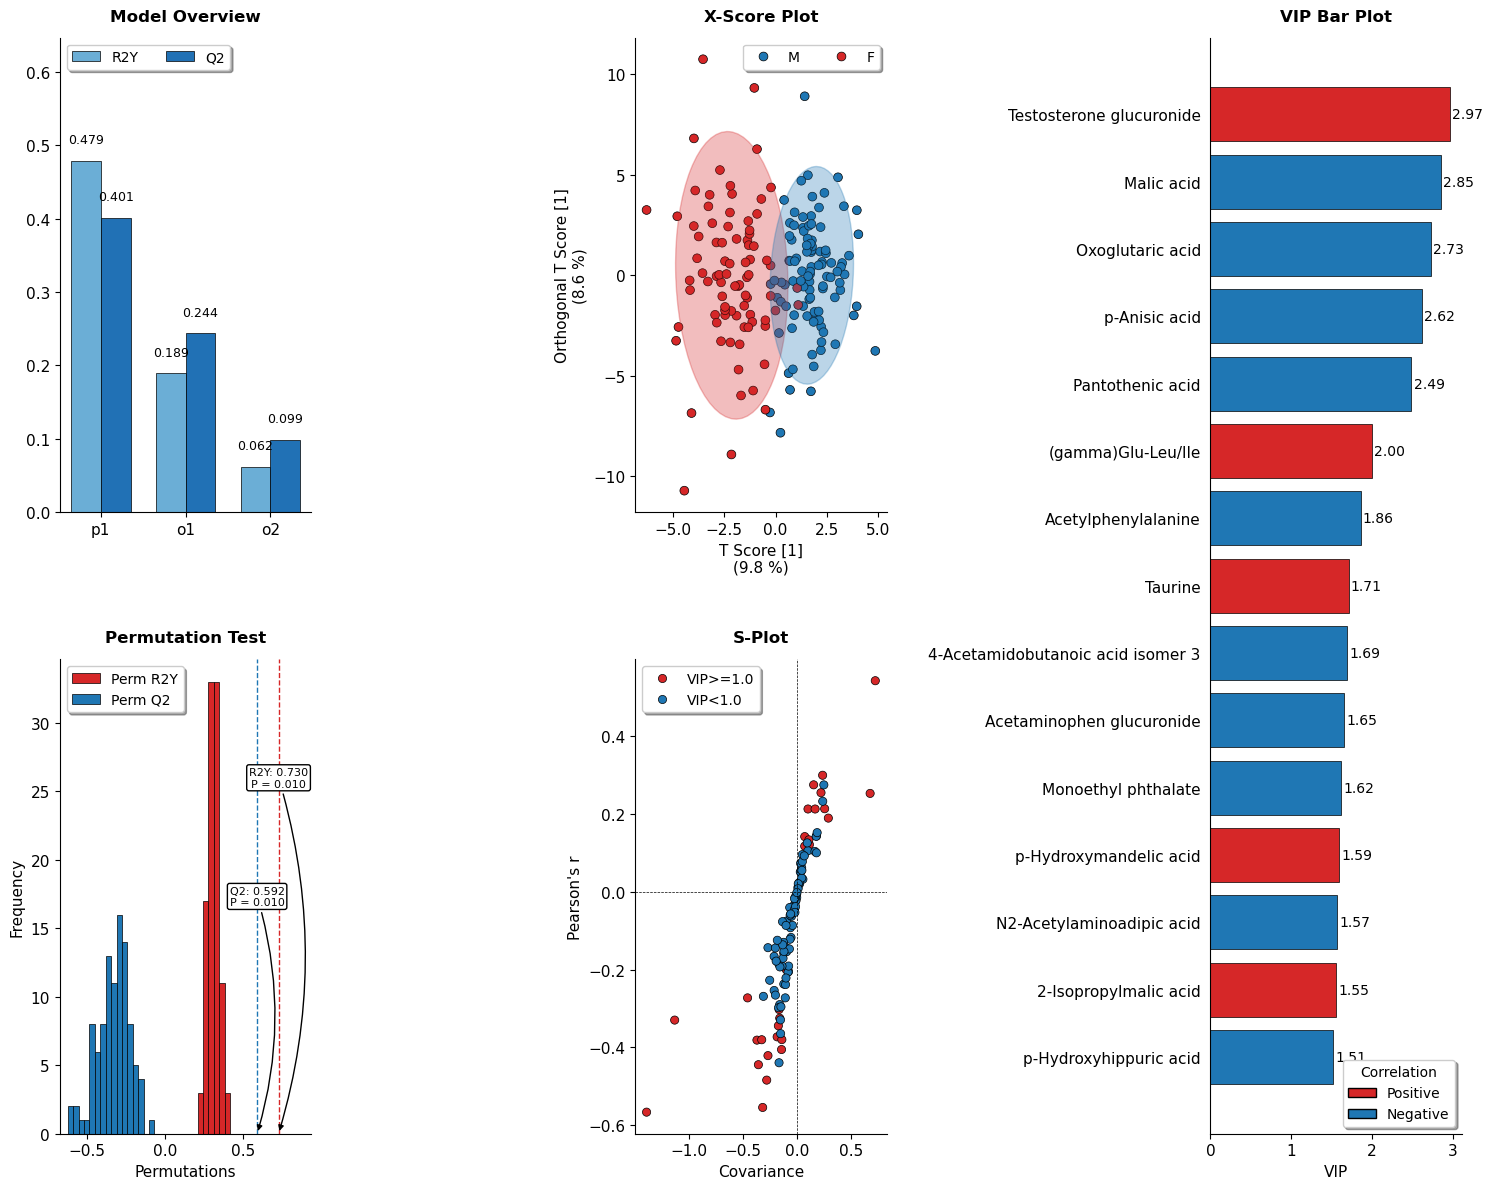

In [3]:
from piopls.oplsda_models import OPLSDA
from piopls.oplsda_plotting import OPLSDA_Visualizer
import pandas as pd

# 1. Load DataFrame
df_X = pd.read_csv("../src/piopls/data/sacurine_X.csv", index_col=0)
df_Y = pd.read_csv("../src/piopls/data/sacurine_Y.csv", index_col=0)
y_data = df_Y.iloc[:, 0].values 

# 2. Model and compute
model_opls = OPLSDA(cv_folds=7)
model_opls.fit(df_X, y_data)
model_opls.compute_q2(df_X, y_data) 
perm_results = model_opls.permutation_test(df_X, y_data, n_perms=100)

# 3. Visualize
vis_opls = OPLSDA_Visualizer(
    model=model_opls, 
    y=y_data, 
    vip_threshold=1.0, 
    top_n_vip=15
)
vis_opls.plot_all(perm_results=perm_results)

In [7]:
# Get model summary information
display(model_opls.get_summary_df())
# Get model scores
display(model_opls.get_scores_df())
# Get model feature scores
display(model_opls.get_features_df())

,Component,R2X,R2Y,Q2
0,p1,0.098442,0.479107,0.401144
1,o1,0.086129,0.189217,0.243941
2,o2,0.090658,0.061509,0.098938


,Sample,t_pred,t_ortho_1,t_ortho_2
0,HU_011,1.582933,4.980604,-5.268184
1,HU_014,-1.372806,1.744338,-0.892428
2,HU_015,3.341370,3.437277,-2.477440
3,HU_017,3.590063,0.979496,-3.557066
4,HU_018,1.662716,-0.315585,3.628218
...,...,...,...,...
178,HU_205,3.020039,0.185278,2.136284
179,HU_206,-0.238014,-1.022405,3.789028
180,HU_207,-4.860766,-3.253181,0.538034
181,HU_208,-1.095204,-5.730609,-0.108418


,Feature,VIP,Covariance,Correlation,p_weight
0,Testosterone glucuronide,2.968444,0.720792,0.541128,0.236541
1,Malic acid,2.854745,-0.320155,-0.554021,-0.242177
2,Oxoglutaric acid,2.729234,-0.373103,-0.381218,-0.166640
3,p-Anisic acid,2.616747,-1.393154,-0.566073,-0.247445
4,Pantothenic acid,2.486306,-0.282849,-0.483856,-0.211506
...,...,...,...,...,...
104,Threonic acid/Erythronic acid,0.069829,-0.111055,-0.272778,-0.119238
105,Cinnamoylglycine,0.066640,-0.195496,-0.178481,-0.078019
106,"1,7-Dimethyluric acid",0.054264,0.007197,0.007357,0.003216
107,Glycocholic acid isomer 2,0.047033,-0.003799,-0.002368,-0.001035
